In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [13]:
path = "city_lifestyle_dataset.csv"
df = pd.read_csv(path)
print(f"Shape: {df.shape}")
df.head()

Shape: (300, 10)


,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


In [15]:
df.describe()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3944.843333,2827.200000,74.305333,1002.766667,71.246667,55.717333,6.644000,33.993333
std,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
min,100.000000,480.000000,34.000000,170.000000,22.000000,15.000000,2.500000,2.000000
25%,1830.000000,1907.500000,64.400000,640.000000,54.000000,46.075000,5.300000,28.225000
50%,3083.500000,2810.000000,75.000000,990.000000,67.500000,54.700000,6.900000,34.700000
75%,4823.750000,3752.500000,87.225000,1332.500000,86.000000,64.200000,8.500000,40.400000
max,14427.000000,5720.000000,100.000000,2430.000000,146.000000,95.000000,8.500000,58.000000


# Task 0 
### a) Determine the categorical and numerical columns

In [16]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns: ", numerical_cols)
print("Categorical columns: ", categorical_cols)

Numerical columns:  ['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']
Categorical columns:  ['city_name', 'country']


### b) Transform categorical values in labels

In [17]:
# encoding categorical columns
for col in categorical_cols:
    labelEncoder = LabelEncoder()
    df[col] = labelEncoder.fit_transform(df[col])

In [18]:
df

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,152,2,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,10,2,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,262,2,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,21,2,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,37,2,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...,...,...
295,145,4,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,191,4,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,130,4,836,3910,98.7,1340,40,55.7,8.5,38.6
298,17,4,758,3490,91.2,1390,36,54.1,8.5,44.6


### c) Scale numerical values using StandardScaler
 

In [19]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [20]:
df

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,152,2,-0.392882,0.852930,0.712033,0.674466,-1.116351,-0.253086,1.102759,-1.082287
1,10,2,-0.028158,0.727843,0.223398,0.718372,-1.155872,0.482207,0.865095,-0.094850
2,262,2,-0.464417,1.236532,0.341141,0.718372,-1.274437,1.190268,1.102759,0.658999
3,21,2,-0.252836,0.953000,0.405900,1.047665,-0.444485,-0.443718,1.102759,1.019997
4,37,2,-0.150740,1.244871,1.512687,1.113524,-0.286399,2.585965,1.102759,0.903203
...,...,...,...,...,...,...,...,...,...,...
295,145,4,-0.987658,1.495046,1.512687,1.091571,-1.234915,0.577523,1.102759,1.720758
296,191,4,-0.770033,1.394976,1.512687,1.420864,-1.076829,-0.436910,1.102759,0.361706
297,130,4,-1.044080,0.902965,1.436154,0.740325,-1.234915,-0.001180,1.102759,0.489117
298,17,4,-1.070275,0.552720,0.994617,0.850089,-1.393001,-0.110113,1.102759,1.126173


In [21]:
# using PCA to visualize the data
pca3 = PCA(n_components=3)
df_pca3 = pca3.fit_transform(df)

pca2 = PCA(n_components=2)
df_pca2 = pca2.fit_transform(df)

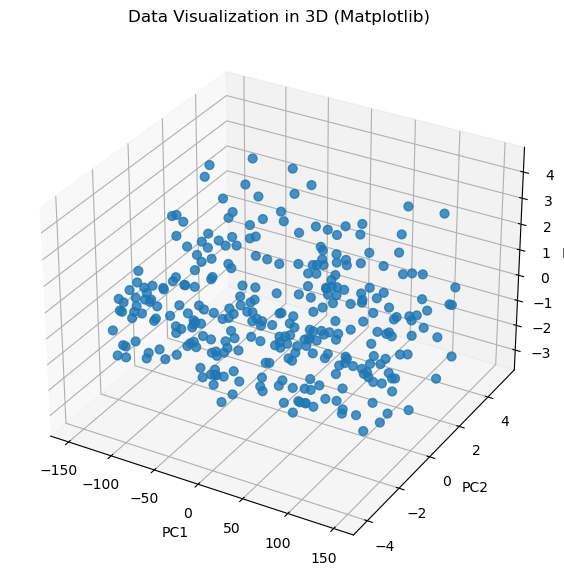

In [37]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

df_plot = pd.DataFrame(df_pca3, columns=['PC1','PC2','PC3'])

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_plot['PC1'], df_plot['PC2'], df_plot['PC3'], s=40, alpha=0.8)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("Data Visualization in 3D (Matplotlib)")
plt.show()


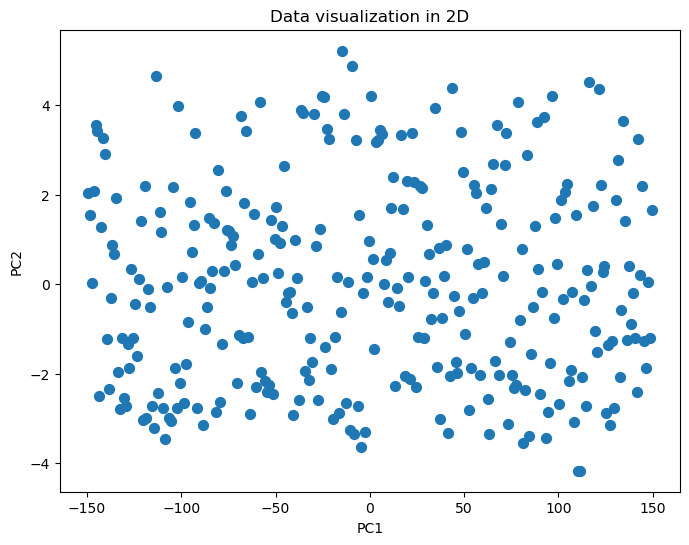

In [23]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca2[:,0], df_pca2[:,1], s=50)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data visualization in 2D")
plt.show()

In [24]:
# kmeans on 2d data
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(df_pca2)

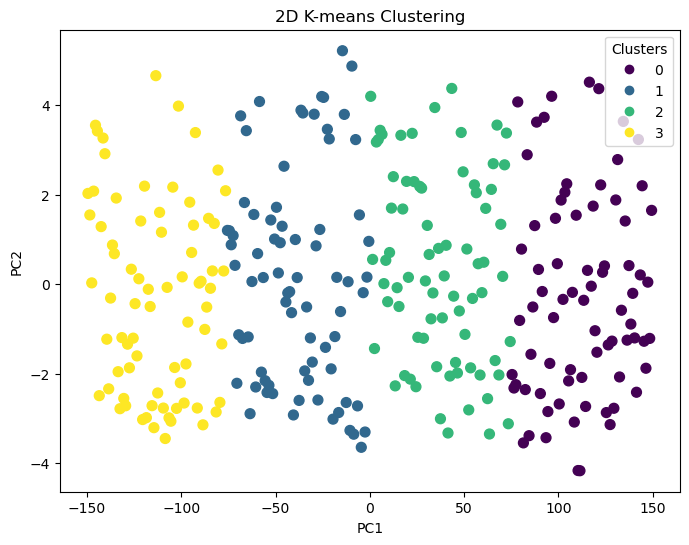

In [25]:

plt.figure(figsize=(8,6))
scatter = plt.scatter(df_pca2[:,0], df_pca2[:,1], c=clusters, s=50)

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D K-means Clustering")
plt.show()


In [26]:
# kmeans on 3d data
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(df_pca3)

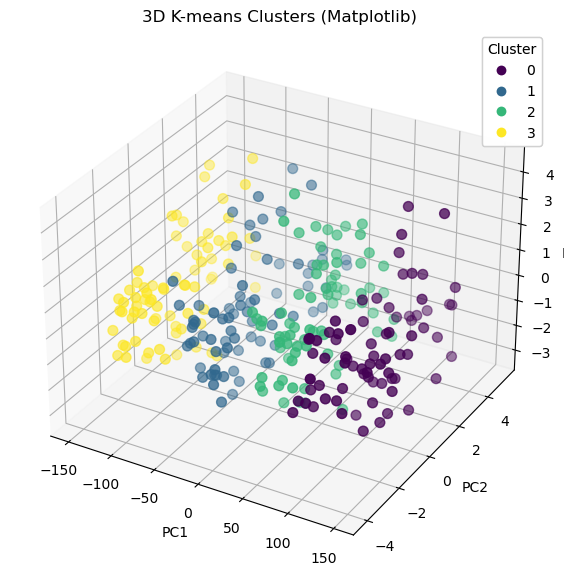

In [38]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

df_plot = pd.DataFrame(df_pca3, columns=['PC1','PC2','PC3'])

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_plot['PC1'], df_plot['PC2'], df_plot['PC3'],
    c=clusters, cmap='viridis', s=50
)

legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D K-means Clusters (Matplotlib)")
plt.show()


# Task 1
### a) Implement K-Means and test it on the city_lifestyle_dataset

### b) Implement the K-Means++ initialization

Standard K-Means initialization picks centroids completely at random, which can lead to poor convergence. K-Means++ selects the first centroid randomly, but selects subsequent centroids based on a weighted probability distribution.

**1. The Minimum Distance ($D(x)$)**
For every data point $x$, we first calculate the distance to the *nearest* centroid that has already been chosen.

$$D(x) = \min_{c \in \mathcal{C}_{chosen}} || x - c ||$$

The term $|| x - c ||$ represents the Euclidean distance. To calculate this for a dataset with $d$ features (dimensions), we use the following expansion:

$$|| x - c || = \sqrt{\sum_{j=1}^{d} (x_j - c_j)^2}$$

**2. The Selection Probability ($P(x)$)**
We select the next centroid from the remaining data points with a probability proportional to the **square** of the distance $D(x)$.

$$P(x) = \frac{D(x)^2}{\sum_{z \in \mathcal{X}} D(z)^2}$$



**Where:**
* $x$: The current data point we are evaluating.
* $\mathcal{C}_{chosen}$: The set of centroids that have already been initialized.
* $x_j$ and $c_j$: The specific feature values (dimensions) for the point and the centroid.
* $d$: The total number of features (columns).
* $\mathcal{X}$: The full set of all data points.
* $z$: An iterator variable representing every point in the dataset (used for the summation).

In [62]:
def initialize_centroids_kmeansPlus(X, k):
    num_points, num_features = X.shape

    chosen_centroids = [X[np.random.randint(0, num_points)]]

    for _ in range(1, k):
        min_dists = np.array([
            min([np.linalg.norm(point - c) for c in chosen_centroids])
            for point in X
        ])

        selection_probs = (min_dists ** 2) / np.sum(min_dists ** 2)

        new_index = np.random.choice(num_points, p=selection_probs)
        chosen_centroids.append(X[new_index])

    return np.array(chosen_centroids)


In [ ]:
def kmeans(X, k=3, max_iters=100, tol=1e-4, k_meansPlus=False):
    """
    X: np.array containing the dataset
    k: no of clusters
    tol: tolerance for changing the centroids
    """
    
    n_samples, n_features = X.shape
    
    if k_meansPlus:
        centroids = initialize_centroids_kmeansPlus(X, k)
    else:
        # choose k random points from n_samples
        centroids = X[np.random.choice(n_samples, k, replace=False)]

    # labels is used for storing the labels of clusters
    labels = np.zeros(n_samples)
    
    for iteration in range(max_iters):
        # assign each point to the closest centroid using the euclidian distance
        for i in range(n_samples):
            #compute euclidean distances between data point and every centroid
            distances = np.linalg.norm(X[i] - centroids, axis=1)
            #choose the index of the closest centroid
            labels[i] = np.argmin(distances)
        
        # calculate the new centroids
        new_centroids = np.zeros((k, n_features))
        for j in range(k):
            points_in_cluster = X[labels == j]
            if len(points_in_cluster) > 0:
                #calculate the new centroid
                new_centroids[j] = points_in_cluster.mean(axis=0)
            else: # empty cluster
                #select random point
                new_centroids[j] = X[np.random.randint(0, n_samples)]
        
        # if the centroids move less than the tolerance threshold, the algorithm has converged
        if np.linalg.norm(new_centroids - centroids) < tol:
            print(f"Converged after {iteration+1} iterations")
            break
        
        centroids = new_centroids
    
    return labels, centroids


Converged after 2 iterations


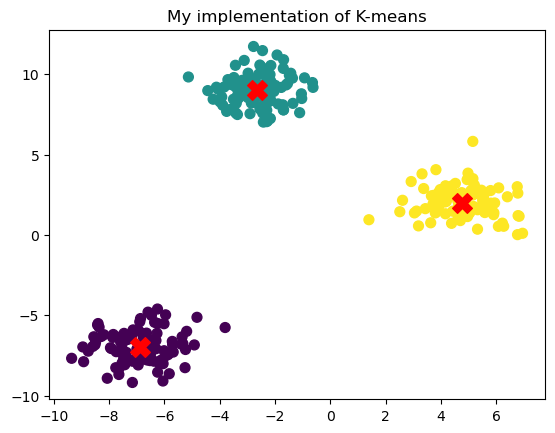

In [68]:
from sklearn.datasets import make_blobs

# artificial data
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

labels, centroids = kmeans(X, k=3, max_iters=100)

plt.scatter(X[:,0], X[:,1], c=labels, s=50)
plt.scatter(centroids[:,0], centroids[:,1], c='red', s=200, marker='X')
plt.title("My implementation of K-means")
plt.show()


# Task 2
Determine the optimal number of clusters $k$ for the provided dataset. To do this, implement the Elbow Method by calculating the Within-Cluster Sum of Squares (WCSS) for a range of $k$ values (e.g., 2 to 10). Plot the results and identify the inflection point where the reduction in variance becomes marginal.

WCSS formula:
$$ WCSS = \sum_{i=1}^{k} \sum_{j=1}^{n_i} || x_j^{(i)} - c_i ||^2 $$

Useful resource: https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

In [75]:
def compute_wcss(X, labels, centroids):
    wcss = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        wcss += np.sum((cluster_points - centroids[i])**2)
    return wcss

wcss_values = []

for k in range(2, 11):
    labels, centroids = kmeans(X, k=k, max_iters=100, k_meansPlus=True)
    wcss = compute_wcss(X, labels, centroids)
    wcss_values.append(wcss)
    print(f"k={k}, WCSS={wcss:.2f}")

Converged after 2 iterations
k=2, WCSS=5763.46
Converged after 2 iterations
k=3, WCSS=566.86
Converged after 10 iterations
k=4, WCSS=496.99
Converged after 9 iterations
k=5, WCSS=444.89
Converged after 8 iterations
k=6, WCSS=375.02
Converged after 13 iterations
k=7, WCSS=376.80
Converged after 9 iterations
k=8, WCSS=315.31
Converged after 11 iterations
k=9, WCSS=323.47
Converged after 8 iterations
k=10, WCSS=246.42


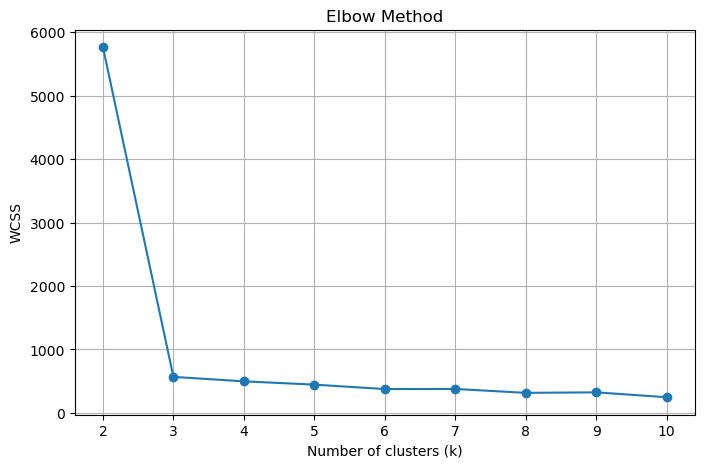

In [76]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), wcss_values, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()